In [2]:
%cd ..
%load_ext autoreload
%autoreload 2

/home/dmatis/s/ssd/rl-optimization/turnus


In [3]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATConv, SAGEConv

class PolicyNetwork(torch.nn.Module):
    def __init__(self, state_size, node_count):
        super().__init__()
        self.state_size = state_size
        self.node_count = node_count

        self.conv1 = GCNConv(state_size, 32)
        self.conv2 = GCNConv(32, 64)
        self.conv3 = GCNConv(64, 64)
        self.conv4 = GCNConv(64, 32)
        self.conv5 = GCNConv(32, 16)
        self.conv6 = GCNConv(16, 1)

        self.activation = F.relu

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.xavier_normal_(module.weight)
            torch.nn.init.zeros_(module.bias)

    def forward(self, data, prnt=False):
        x, edge_index = data.x[:, [0]], data.adj_t if hasattr(data, 'adj_t') else data.edge_index

        if prnt: print(x)
        x = self.activation(self.conv1(x, edge_index))
        if prnt: print(len(x.nonzero()), x)
        x = self.activation(self.conv2(x, edge_index))
        if prnt: print(len(x.nonzero()), x)
        x = self.activation(self.conv3(x, edge_index))
        if prnt: print(len(x.nonzero()), x)
        x = self.activation(self.conv4(x, edge_index))
        if prnt: print(len(x.nonzero()), x)
        x = self.activation(self.conv5(x, edge_index))
        if prnt: print(len(x.nonzero()), x)

        x = self.conv6(x, edge_index)
        if prnt: print(len(x.nonzero()), x)

        return x.view(-1, self.node_count), None, None

In [ ]:
import time
import torch
from env import Env
import utils.graph_utils as graph_utils
import torch.nn.functional as F

def e_greedy_eval(net: torch.nn.Module, env: Env):
    observation, mask = env.reset()
    terminal = False

    first = False

    r_sum = 0
    while not terminal:
        logit, ext_value, int_value = net(observation, prnt=first)

        if first:
            print('Logit: ', logit.detach().cpu())
            first = False

        logit = torch.where(mask, logit, torch.tensor(-1e+8, device=logit.device))
        probs = F.softmax(logit, dim=-1)
        action = probs.argmax()
        observation, mask, reward, terminal, _ = env.step(action.item())
        r_sum += reward

    return observation, r_sum, env.vehicleID - 1

def random_eval(env: Env):
    state, mask = env.reset()

    terminal = False

    r_sum = 0
    while not terminal:
        indices = mask.nonzero(as_tuple=True)[0]
        action = indices[torch.randint(0, len(indices), (1,))] # pick random action
        observation, mask, reward, terminal, _ = env.step(action.item())
        r_sum += reward

    return observation, r_sum, env.vehicleID - 1


results = {}
for i in range(100):
    
    net = PolicyNetwork(1, 1).to(device)
    print(f'Creating new model {i}')

    # with torch.no_grad():
    #     for name, param in net.named_parameters():
    #         if 'weight' in name:
    #             param.sub_(param.std() / 5)
    #             pass

    net.eval()

    for problem in range(0, 11):
        graph, optimal = graph_utils.load_problem(f'data/{problem}')

        env = Env(graph = graph, optimal = optimal, device=device)

        net.node_count = env.action_space()

        if problem not in results:
            results[problem] = []

        start = time.time()
        observation, _, vehicles = e_greedy_eval(net, env)
        # observation, _, vehicles = random_eval(env)
        took = round(time.time() - start, 2)

        gap = vehicles / optimal

        results[problem].append([1 if gap <= 1.15 else 0, gap, vehicles])

        print(f'Problem {problem} ({graph.num_nodes} nodes); \t agent: {vehicles} (opt. {optimal}) - it took {took}s')

In [14]:
graph.x

tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
      

In [21]:
import numpy as np
res = np.array(list(results.values()))

nodes = [6, 51, 79, 85, 107, 135, 162, 247, 417, 496, 929]
optimal = [2, 4, 4, 5, 6, 8, 9, 13, 26, 28, 49]

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.plot(nodes, res[:, :, 0].sum(axis=1))
plt.scatter(nodes, res[:, :, 0].sum(axis=1))
plt.xlabel('Problem size')
plt.ylabel('[%]')
plt.title('Percentage of finding optimal solution across different problem sizes with random NN')

In [19]:
res.shape

(10, 100, 3)

In [17]:
# Difference from optimal
res[:, :, 2] - np.array(optimal)[:, np.newaxis]

ValueError: operands could not be broadcast together with shapes (10,100) (11,1) 

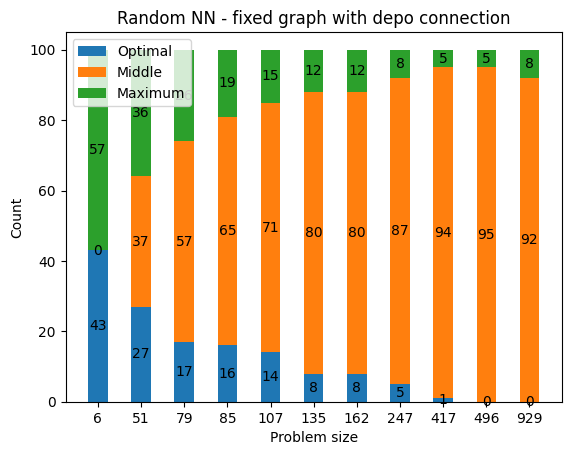

In [22]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots()
bottom = np.zeros(res.shape[0])
width = 0.45

opt = (res[:, :, 1] <= 1.15).sum(axis=1)
maxi = (res[:, :, 2] == (np.array(nodes) - 2)[:, np.newaxis]).sum(axis=1)
mid = res.shape[1] - (opt + maxi)

sols = {
    'Optimal': opt,
    'Middle': mid,
    'Maximum': maxi
}

for name, count in sols.items():
    p = ax.bar(list(map(str, nodes)), count, width, label=name, bottom=bottom)
    bottom += count

    ax.bar_label(p, label_type='center')

ax.set_title('Random NN - fixed graph with depo connection')
ax.set_ylabel('Count')
ax.set_xlabel('Problem size')
ax.legend()
plt.show()

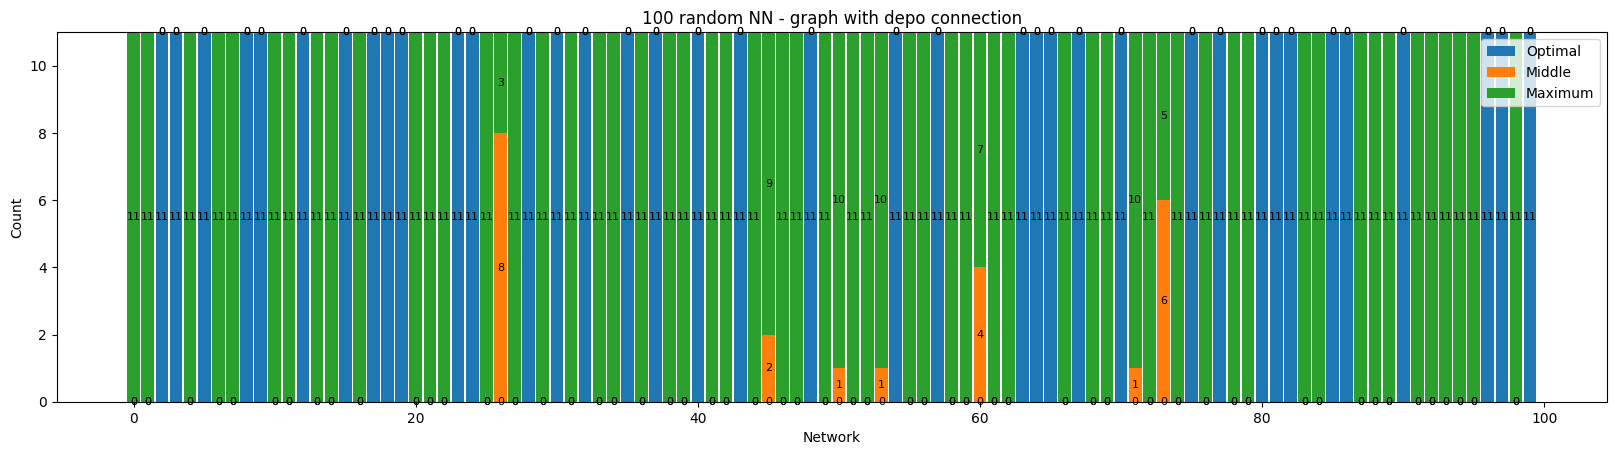

In [10]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots()
bottom = np.zeros(res.shape[1])
width = 0.9

#make figure wider
fig.set_figwidth(20)

opt = (res[:, :, 1] <= 1.15).sum(axis=0)
maxi = (res[:, :, 2] == (np.array(nodes) - 2)[:, np.newaxis]).sum(axis=0)
mid = res.shape[0] - opt - maxi

sols = {
    'Optimal': opt,
    'Middle': mid,
    'Maximum': maxi
}

for name, count in sols.items():
    p = ax.bar(list(range(len(bottom))), count, width, label=name, bottom=bottom)
    bottom += count

    ax.bar_label(p, label_type='center', size=8)

ax.set_title('100 random NN - graph with depo connection')
ax.set_ylabel('Count')
ax.set_xlabel('Network')
ax.legend()
plt.show()

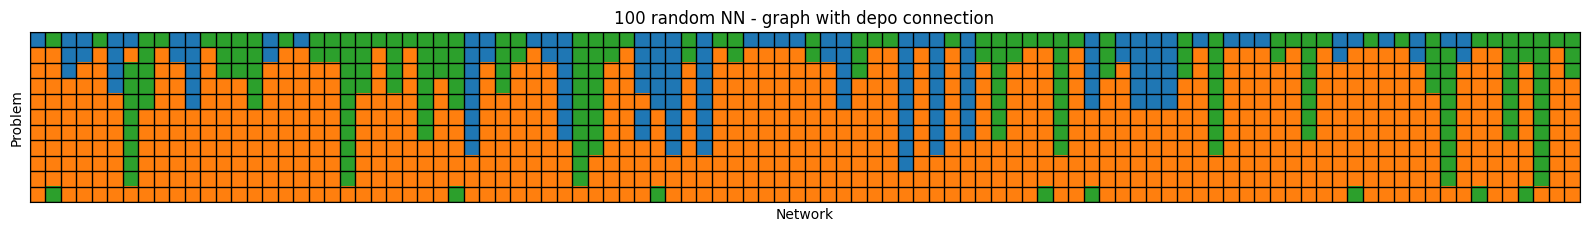

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors

data = np.zeros((res.shape[0], res.shape[1])) + 1

opt = (res[:, :, 1] <= 1.15)
maxi = (res[:, :, 2] == (np.array(nodes) - 2)[:, np.newaxis])

data[opt] = 0
data[maxi] = 2

# create discrete colormap
cmap = colors.ListedColormap(['tab:blue', 'tab:orange', 'tab:green'])

fig, ax = plt.subplots()
fig.set_figwidth(20)
ax.imshow(data, cmap=cmap)

plt.grid(axis='both', color='k', linewidth=1) 
plt.xticks(np.arange(-0.5, data.shape[1], 1))
plt.yticks(np.arange(-0.5, data.shape[0], 1))

plt.tick_params(bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)

ax.set_title(f"{data.shape[1]} random NN - graph with depo connection")
ax.set_ylabel('Problem')
ax.set_xlabel('Network')
plt.show()